In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

from dotenv import load_dotenv
load_dotenv()

from app.services.redismanager import redismanager
from datetime import datetime, timedelta
import pandas as pd


def obtener_contexto_pronostico():
    """
    Lee el último pronóstico de Redis y lo convierte en contexto para el LLM.
    
    Returns:
        str: Contexto formateado o string vacío si no hay datos.
    """
    try:
        ultima_pred = redismanager.obtener_prediction()
        
        if ultima_pred is not None and not ultima_pred.empty:
            fecha = ultima_pred.iloc[0]['date']
            fecha = pd.to_datetime(fecha_str).strftime('%Y-%m-%d %H:%M:%S')
            contexto = f"\n\nÚltimo pronóstico de PM2.5 (fecha de inferencia: {fecha}):\n"
            for h in range(1, 8):
                fecha_pronostico = pd.to_datetime(fecha) + timedelta(hours=h)
                valor = ultima_pred.iloc[0][f'pm2.5_(t+{h})']
                contexto += f"- horizonte{h} - {fecha_pronostico}: {valor} µg/m³\n"
            return contexto
    except Exception as e:
        print(f"Error al obtener contexto: {e}")
    
    return ""

print(obtener_contexto_pronostico())



Último pronóstico de PM2.5 (fecha de inferencia: 2026-06-08T17:00:00):
- h1: 21.82 µg/m³
- h2: 28.8 µg/m³
- h3: 36.1 µg/m³
- h4: 45.83 µg/m³
- h5: 45.64 µg/m³
- h6: 56.53 µg/m³
- h7: 58.04 µg/m³



# Entrenamiento XGBoost — Pronóstico horario de PM2.5 (h1..h7)

**Autores:** Carlos Enrique Gómez · Silvana María López
**Proyecto final del bootcamp**

---

## Objetivo

Entrenar un modelo **XGBoost** por cada horizonte de pronóstico ($t+1$ hasta $t+7$ horas) sobre el dataset *Beijing PM2.5*, utiliza las mismas entradas que el RF para que los resultados sean directamente comparables.

## Diferencias clave frente a Random Forest

| Aspecto | Random Forest (compañero) | XGBoost (este notebook) |
|---|---|---|
| Tipo de algoritmo | Bagging de árboles independientes | Boosting de árboles secuenciales |
| `n_estimators` | Fijado por Optuna en cada trial | **Determinado por *early stopping*** |
| Regularización L1/L2 | No tiene | `reg_alpha`, `reg_lambda` en el search space |
| Penalización de ganancias | No tiene | `gamma`, `min_child_weight` |
| Manejo de NaN | Imputación interna por sklearn | Manejo nativo (split por defecto) |


**Early stopping** es la herramienta de regularización más importante que aporta XGBoost: en lugar de fijar el número de árboles...sino que  el entrenamiento se detiene automáticamente cuando la pérdida en validación deja de mejorar durante `early_stopping_rounds=50` iteraciones consecutivas (le puse 50... de manera al azar). 

## Estructura del notebook

1. Los datos se ingresan igualitos que como en RF (one-hot, lags, targets, MinMaxScaler) 
3. Estrategia de validación: con early stopping, en la sección lo explico
4. Función `entrenar_horizonte(h)` con búsqueda de hiperparámetros (Optuna) y entrenamiento final
5. Loop h1..h7
6. Tabla resumen comparativa y visualizaciones por horizonte
7. Guardado de modelos `.joblib` y predicciones `.csv`

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib

import xgboost as xgb
import optuna
from optuna.pruners import MedianPruner

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score,
    mean_absolute_percentage_error,
)

# Silenciar logs de Optuna (deja solo lo importante) porque son horriblemente ruidososss
optuna.logging.set_verbosity(optuna.logging.WARNING)


print("xgboost:", xgb.__version__)
print("optuna :", optuna.__version__)

xgboost: 3.2.0
optuna : 4.6.0


## Pipeline de datos — réplica exacta del notebook RF

Este notebook: carga del **CSV imputado** producido por el EDA consolidado (sin NaN en `pm2.5`, mismas 13 columnas originales).

Esto evita duplicar la imputación y garantiza que ambos modelos parten del mismo target.


In [3]:
# Carga del dataset imputado (producto del EDA)
RUTA_CSV = "beijing_pm25_imputado.csv"
# Si lo corres en Colab, cambia la ruta:
# RUTA_CSV = "/content/drive/MyDrive/AI_Bootcamp/Datos/beijing_pm25_imputado.csv"

df = pd.read_csv(RUTA_CSV, parse_dates=["datetime"])
df = df.set_index("datetime")
df.index.name = "date"
print(f"Shape: {df.shape}")
print(f"Rango: {df.index.min()}  →  {df.index.max()}")
print(f"Nulos en pm2.5: {df['pm2.5'].isnull().sum()}")
df.head()

Shape: (43824, 12)
Rango: 2010-01-01 00:00:00  →  2014-12-31 23:00:00
Nulos en pm2.5: 0


,year,month,day,hour,pm2.5,DEWP,TEMP,PRES,cbwd,Iws,Is,Ir
date,,,,,,,,,,,,
2010-01-01 00:00:00,2010,1,1,0,104.5,-21,-11.0,1021.0,NW,1.79,0,0
2010-01-01 01:00:00,2010,1,1,1,85.0,-21,-12.0,1020.0,NW,4.92,0,0
2010-01-01 02:00:00,2010,1,1,2,75.5,-21,-11.0,1019.0,NW,6.71,0,0
2010-01-01 03:00:00,2010,1,1,3,63.5,-21,-14.0,1019.0,NW,9.84,0,0
2010-01-01 04:00:00,2010,1,1,4,56.5,-20,-12.0,1018.0,NW,12.97,0,0


In [ ]:
# One-hot encoding para cbwd y month
df = pd.get_dummies(df, columns=["cbwd"],  prefix="", prefix_sep="cbwd_",  dtype=int)
df = pd.get_dummies(df, columns=["month"], prefix="", prefix_sep="month_", dtype=int)

# Eliminamos componentes de fecha 
df = df.drop(columns=["year", "day", "hour"])

print(f"Columnas tras one-hot ({len(df.columns)}):")
print(df.columns.tolist())

Columnas tras one-hot (23):
['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12']


In [ ]:
# Construcción de lags hacia atrás (variables explicativas) 
N_LAGS = 7
variables_lag = ["pm2.5", "DEWP", "TEMP", "PRES", "Iws"]

for variable in variables_lag:
    for i in range(1, N_LAGS + 1):
        df[f"{variable}_(t-{i})"] = df[variable].shift(i)

# Targets hacia adelante para los 7 horizontes
MAX_HORIZON = 7
leads = list(range(1, MAX_HORIZON + 1))

for lead in leads:
    df[f"pm2.5_(t+{lead})"] = df["pm2.5"].shift(-lead)

print(f"Total columnas: {len(df.columns)}")
print(f"Features (sin targets): {len([c for c in df.columns if not c.startswith('pm2.5_(t+')])}")
print(f"Targets: {[c for c in df.columns if c.startswith('pm2.5_(t+')]}")

Total columnas: 65
Features (sin targets): 58
Targets: ['pm2.5_(t+1)', 'pm2.5_(t+2)', 'pm2.5_(t+3)', 'pm2.5_(t+4)', 'pm2.5_(t+5)', 'pm2.5_(t+6)', 'pm2.5_(t+7)']


In [6]:
# Matriz de features X (todo lo que NO es un target a futuro)
keep_cols = [col for col in df.columns if not col.startswith("pm2.5_(t+")]
X = df[keep_cols]

print(f"X shape: {X.shape}")
print(f"Columnas en X ({len(X.columns)}):")
print(X.columns.tolist())

X shape: (43824, 58)
Columnas en X (58):
['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws', 'Is', 'Ir', 'cbwd_NE', 'cbwd_NW', 'cbwd_SE', 'cbwd_cv', 'month_1', 'month_2', 'month_3', 'month_4', 'month_5', 'month_6', 'month_7', 'month_8', 'month_9', 'month_10', 'month_11', 'month_12', 'pm2.5_(t-1)', 'pm2.5_(t-2)', 'pm2.5_(t-3)', 'pm2.5_(t-4)', 'pm2.5_(t-5)', 'pm2.5_(t-6)', 'pm2.5_(t-7)', 'DEWP_(t-1)', 'DEWP_(t-2)', 'DEWP_(t-3)', 'DEWP_(t-4)', 'DEWP_(t-5)', 'DEWP_(t-6)', 'DEWP_(t-7)', 'TEMP_(t-1)', 'TEMP_(t-2)', 'TEMP_(t-3)', 'TEMP_(t-4)', 'TEMP_(t-5)', 'TEMP_(t-6)', 'TEMP_(t-7)', 'PRES_(t-1)', 'PRES_(t-2)', 'PRES_(t-3)', 'PRES_(t-4)', 'PRES_(t-5)', 'PRES_(t-6)', 'PRES_(t-7)', 'Iws_(t-1)', 'Iws_(t-2)', 'Iws_(t-3)', 'Iws_(t-4)', 'Iws_(t-5)', 'Iws_(t-6)', 'Iws_(t-7)']


## Escalado MinMax — idéntico al notebook RF

Carlos estuv eleyendo... y ...apenas me vengo a desayunar que  XGBoost (como Random Forest) es **invariante a transformaciones monotónicas**, entonces supuestamente no necesita escalado, mijo lo de gotta jaaja bueno, mantenemos `MinMaxScaler` en esto.

El scaler de X y los 7 scalers de y (uno por horizonte) se guardan.

In [7]:
# Ruta de guardado de modelos (cámbiala si corres fuera de Colab)
RUTA_MODELS = "models_xgb"
import os
os.makedirs(RUTA_MODELS, exist_ok=True)
print(f"Modelos se guardarán en: {RUTA_MODELS}")

Modelos se guardarán en: models_xgb


In [8]:
# Escalado de X (mismo procedimiento que el notebook RF)
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns, index=X.index)

joblib.dump(scaler_X, f"{RUTA_MODELS}/X_scaler.joblib")
print(f"✓ Scaler de X guardado")
print(f"  X_scaled shape: {X_scaled.shape}")
print(f"  X tiene NaN? {X_scaled.isna().any().any()}  (esperado True por los lags iniciales)")

✓ Scaler de X guardado
  X_scaled shape: (43824, 58)
  X tiene NaN? True  (esperado True por los lags iniciales)


In [ ]:
# Escalado de cada target 
y_scaled_dict = {}

for h in leads:
    scaler_y = MinMaxScaler()
    y_raw = df[f"pm2.5_(t+{h})"].values.reshape(-1, 1)
    y_scaled = scaler_y.fit_transform(y_raw)
    y_scaled_dict[f"h{h}"] = pd.DataFrame(
        y_scaled,
        columns=[f"pm2.5_(t+{h})_scaled"],
        index=df.index
    )
    joblib.dump(scaler_y, f"{RUTA_MODELS}/y_h{h}_scaler.joblib")

print(f"✓ {len(leads)} scalers de target guardados (uno por horizonte)")

✓ 7 scalers de target guardados (uno por horizonte)


## Estrategia de validación —early stopping

Early stopping requiere un conjunto de validación que el modelo **no haya visto durante `fit()`**, para decidir cuándo detener el aprendizaje. Pero el flujo del notebook RF entrena el modelo final sobre `train + val` (todos los datos disponibles antes de test), lo que dejaría sin holdout para hacer early stopping.

### IMPORTANTE, con este early stopping ...
1. **Conserva la cronología**: el holdout de early stopping son las últimas semanas de 2013, las más recientes antes del test 2014.
2. **Casi todos los datos disponibles entran al modelo** (≈ 99% de train+val).
3. **El test (2014) sigue siendo un conjunto verdaderamente no visto** — ni para tuning, ni para early stopping.
4. **Coherente con la literatura**: es la práctica recomendada en guías oficiales de XGBoost para series temporales.

### Entonces funciona maso así:

```
2010 ─────────────────────────── 2012-12-31 │ 2013-01-01 ───── 2013-12-31 │ 2014-01-01 ─── 2014-12-31
              X_train                       │            X_val             │           X_test
                                            │   X_val[:90%]  │ X_es (10%)  │
                                            │                │             │
                  Optuna usa:               │  X_train para entrenar       │      (test no tocado)
                                            │  X_val para early stop       │
                                            │                              │
                  Modelo final usa:         │  X_train + X_val[:90%]       │      (test no tocado)
                                            │                  X_es = early stop                
```

In [10]:
# Splits cronológicos (idénticos al notebook RF para las fronteras train/val/test)
TRAIN_END = "2012-12-31"
VAL_END   = "2013-12-31"

print(f"Train: hasta {TRAIN_END}")
print(f"Val  : {TRAIN_END}  →  {VAL_END}")
print(f"Test : después de {VAL_END}")
print(f"\nDentro de val, usaremos el último 10% como holdout de early stopping en el modelo final.")

Train: hasta 2012-12-31
Val  : 2012-12-31  →  2013-12-31
Test : después de 2013-12-31

Dentro de val, usaremos el último 10% como holdout de early stopping en el modelo final.


## 5. Función `entrenar_horizonte(h)`

Encapsula todo el proceso para un solo horizonte $t+h$:

1. **Preparar los datos**: filtra filas con target válido, hace el split cronológico.
2. **Optuna (puse 100 trials)**: busca hiperparámetros que minimicen el MSE en validación, dejando que early stopping determine `n_estimators` por trial.
3. **Predicciones**: sobre train original, val original y test.
4. **Métricas**: MSE, RMSE, MAE, R², MAPE en escala original (no escalada) — para que sean interpretables en µg/m³.
5. **Guarda**: modelo `.joblib` y predicciones `.csv`.

Devuelve un diccionario con todo lo necesario para construir la tabla resumen al final.

In [11]:
def split_data(h):
    """Prepara X, y, splits cronológicos para el horizonte h.

    Mantiene la lógica del compañero (RF): el target NaN se descarta, las X
    pueden tener NaN (XGBoost los maneja nativamente).
    """
    y_h = y_scaled_dict[f"h{h}"]
    # Filas válidas: aquellas donde el target no es NaN (las últimas h horas siempre lo son)
    valid_idx = y_h.notna().squeeze()
    X_clean = X_scaled[valid_idx]
    y_clean = y_h[valid_idx]

    X_tr = X_clean.loc[:TRAIN_END]
    X_vl = X_clean.loc[TRAIN_END:VAL_END]
    X_te = X_clean.loc[VAL_END:]

    y_tr = y_clean.loc[:TRAIN_END]
    y_vl = y_clean.loc[TRAIN_END:VAL_END]
    y_te = y_clean.loc[VAL_END:]

    return X_tr, X_vl, X_te, y_tr, y_vl, y_te


# Test rápido para h1
X_tr, X_vl, X_te, y_tr, y_vl, y_te = split_data(1)
print(f"Split h1:  train={len(X_tr):,}  val={len(X_vl):,}  test={len(X_te):,}")

Split h1:  train=26,304  val=8,784  test=8,783


In [12]:
# Espacio de búsqueda de Optuna
def make_objective(X_tr, X_vl, y_tr, y_vl, n_estimators_max=2000, es_rounds=50):
    """Crea la función objetivo para Optuna para un (X_tr, y_tr, X_vl, y_vl) específico.

    El espacio de búsqueda cubre los hiperparámetros más relevantes de XGBoost:
    - learning_rate     log-uniform [0.01, 0.3]   — tasa de aprendizaje
    - max_depth         int [3, 12]                — profundidad del árbol
    - min_child_weight  int [1, 10]                — mínima suma de pesos en hoja
    - subsample         uniform [0.6, 1.0]         — % de filas por árbol
    - colsample_bytree  uniform [0.6, 1.0]         — % de columnas por árbol
    - gamma             log-uniform [1e-3, 10]     — mínima ganancia para splittear
    - reg_alpha         log-uniform [1e-3, 10]     — regularización L1
    - reg_lambda        log-uniform [1e-3, 10]     — regularización L2

    `n_estimators` se fija en n_estimators_max (techo alto, e.g. 2000) y early stopping
    decide el número real de árboles por trial. Esto desacopla la búsqueda de hiperparámetros
    del número de árboles, que sería redundante con learning_rate.
    """
    def objective(trial):
        params = {
            "learning_rate":    trial.suggest_float("learning_rate",    0.01, 0.3,  log=True),
            "max_depth":        trial.suggest_int  ("max_depth",        3,    12),
            "min_child_weight": trial.suggest_int  ("min_child_weight", 1,    10),
            "subsample":        trial.suggest_float("subsample",        0.6,  1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6,  1.0),
            "gamma":            trial.suggest_float("gamma",            1e-3, 10,   log=True),
            "reg_alpha":        trial.suggest_float("reg_alpha",        1e-3, 10,   log=True),
            "reg_lambda":       trial.suggest_float("reg_lambda",       1e-3, 10,   log=True),
        }

        model = xgb.XGBRegressor(
            n_estimators=n_estimators_max,
            early_stopping_rounds=es_rounds,
            eval_metric="rmse",
            tree_method="hist",          # rápido para datasets medianos
            random_state=RND,
            verbosity=0,
            **params,
        )
        model.fit(
            X_tr, y_tr.values.ravel(),
            eval_set=[(X_vl, y_vl.values.ravel())],
            verbose=False,
        )

        # Reportamos el best_iteration encontrado por early stopping
        # (queda guardado en el trial para inspección posterior)
        trial.set_user_attr("best_iteration", int(model.best_iteration))

        # Métrica a optimizar: MSE en val (consistente con notebook RF)
        y_pred = model.predict(X_vl)
        return mean_squared_error(y_vl, y_pred)

    return objective

In [ ]:
def calculate_metrics(y_true, y_pred, set_name):
    """Mismo conjunto de métricas que RF, en la misma estructura.

    Nota sobre MAPE: el dataset contiene unas pocas mediciones con pm2.5 = 0 µg/m³
    (mínimos absolutos del periodo) y otras muy próximas a 0. MAPE divide entre el valor
    real, por lo que esos casos producen valores muy grandes que distorsionan el promedio.
    Para evitar infinitos pero mantener consistencia con la métrica ,
    calculé MAPE solo sobre las filas con |y_true| >= 1 µg/m³ (todo el rango relevante
    para calidad del aire). El MAPE así calculado es interpretable como error porcentual
    promedio en la escala útil del problema.
    """
    mask = np.abs(y_true) >= 1.0
    mape = mean_absolute_percentage_error(y_true[mask], y_pred[mask]) if mask.sum() > 0 else np.nan

    return {
        "Set":  set_name,
        "MSE":  mean_squared_error(y_true, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_true, y_pred)),
        "MAE":  mean_absolute_error(y_true, y_pred),
        "R2":   r2_score(y_true, y_pred),
        "MAPE": mape,
    }

In [ ]:
def entrenar_horizonte(h, n_trials=50, es_rounds=50, n_estimators_max=2000, verbose=True):
    """Pipeline completa de entrenamiento XGBoost para el horizonte h.

    Pasos:
      1. Split cronológico
      2. Optuna con early stopping en cada trial
      3. Modelo final con ealy stippoin
      4. Predicciones + métricas + guardado
    """
    if verbose:
        print(f"\n{'='*80}\n  ENTRENANDO HORIZONTE h{h}  (target: pm2.5_(t+{h}))\n{'='*80}")

    # ----- (1) Split de datos -----
    X_tr, X_vl, X_te, y_tr, y_vl, y_te = split_data(h)
    if verbose:
        print(f"\n[1/4] Split:  train={len(X_tr):,}  val={len(X_vl):,}  test={len(X_te):,}")

    # ----- (2) Optuna -----
    if verbose:
        print(f"\n[2/4] Optuna ({n_trials} trials) buscando hiperparámetros...")

    study = optuna.create_study(direction="minimize", pruner=MedianPruner(),
                                sampler=optuna.samplers.TPESampler(seed=RND))
    objective = make_objective(X_tr, X_vl, y_tr, y_vl,
                               n_estimators_max=n_estimators_max,
                               es_rounds=es_rounds)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=False)

    best_params = study.best_params
    best_iter_optuna = study.best_trial.user_attrs["best_iteration"]
    if verbose:
        print(f"      MSE_val óptimo (escalado): {study.best_value:.6e}")
        print(f"      best_iteration del mejor trial: {best_iter_optuna}")
        print(f"      Hiperparámetros:")
        for k, v in best_params.items():
            print(f"        {k}: {v if not isinstance(v, float) else round(v, 4)}")

    # ----- (3) Modelo final — Opción C -----
    if verbose:
        print(f"\n[3/4] Entrenando modelo final (Opción C):")

    n_val = len(X_vl)
    split_idx = int(n_val * 0.9)   # 90% de val → entrenamiento, 10% → early stop

    X_full = pd.concat([X_tr, X_vl.iloc[:split_idx]])
    y_full = pd.concat([y_tr, y_vl.iloc[:split_idx]])
    X_es = X_vl.iloc[split_idx:]
    y_es = y_vl.iloc[split_idx:]

    if verbose:
        print(f"      Entrenamiento final: {len(X_full):,} filas (train + 90% de val)")
        print(f"      Holdout early-stop:  {len(X_es):,} filas (último 10% de val)")

    model_final = xgb.XGBRegressor(
        n_estimators=n_estimators_max,
        early_stopping_rounds=es_rounds,
        eval_metric="rmse",
        tree_method="hist",
        random_state=RND,
        verbosity=0,
        **best_params,
    )
    model_final.fit(
        X_full, y_full.values.ravel(),
        eval_set=[(X_es, y_es.values.ravel())],
        verbose=False,
    )
    if verbose:
        print(f"      best_iteration del modelo final: {model_final.best_iteration} árboles")

    # ----- (4) Predicciones, métricas, guardado -----
    if verbose:
        print(f"\n[4/4] Predicciones y métricas...")

    # Predecimos en cada set original (no en el split de early stopping)
    y_tr_pred = model_final.predict(X_tr)
    y_vl_pred = model_final.predict(X_vl)
    y_te_pred = model_final.predict(X_te)

    # Métricas: las calculamos en escala ORIGINAL (no escalada) para que sean
    # interpretables en µg/m³. Para eso aplicamos inverse_transform del scaler del target.
    sc_y = joblib.load(f"{RUTA_MODELS}/y_h{h}_scaler.joblib")

    def inv(arr):
        return sc_y.inverse_transform(arr.reshape(-1, 1)).ravel()

    metrics = [
        calculate_metrics(inv(y_tr.values.ravel()), inv(y_tr_pred), "Train"),
        calculate_metrics(inv(y_vl.values.ravel()), inv(y_vl_pred), "Validation"),
        calculate_metrics(inv(y_te.values.ravel()), inv(y_te_pred), "Test"),
    ]
    metrics_df = pd.DataFrame(metrics)
    metrics_df.insert(0, "horizonte", f"h{h}")

    if verbose:
        print(f"\n  Métricas (escala original µg/m³):")
        print(metrics_df.round(3).to_string(index=False))

    # Guardar modelo
    joblib.dump(model_final, f"{RUTA_MODELS}/model_xgb_h{h}.joblib")
    if verbose:
        print(f"\n  ✓ Modelo guardado: model_xgb_h{h}.joblib")

    # ==================== GRÁFICA ====================
    # Si querés escala original (µg/m³), usá las versiones invertidas que ya calculamos.
    # Si querés escala escalada [0,1] como el compañero, cambiá inv(...) por las versiones .values.ravel().
    fig, axes = plt.subplots(3, 1, figsize=(14, 10))

    axes[0].plot(y_tr.index, inv(y_tr.values.ravel()), label="Real",     linewidth=2, marker="o", markersize=3)
    axes[0].plot(y_tr.index, inv(y_tr_pred),           label="Predicho", linewidth=2, marker="s", markersize=3)
    axes[0].set_title(f"TRAIN h{h} (t+{h}h) — Real vs Predicho", fontsize=12, fontweight="bold")
    axes[0].set_ylabel("PM2.5 (µg/m³)", fontsize=10)
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    axes[1].plot(y_vl.index, inv(y_vl.values.ravel()), label="Real",     linewidth=2, marker="o", markersize=3)
    axes[1].plot(y_vl.index, inv(y_vl_pred),           label="Predicho", linewidth=2, marker="s", markersize=3)
    axes[1].set_title(f"VALIDATION h{h} (t+{h}h) — Real vs Predicho", fontsize=12, fontweight="bold")
    axes[1].set_ylabel("PM2.5 (µg/m³)", fontsize=10)
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    axes[2].plot(y_te.index, inv(y_te.values.ravel()), label="Real",     linewidth=2, marker="o", markersize=3)
    axes[2].plot(y_te.index, inv(y_te_pred),           label="Predicho", linewidth=2, marker="s", markersize=3)
    axes[2].set_title(f"TEST h{h} (t+{h}h) — Real vs Predicho", fontsize=12, fontweight="bold")
    axes[2].set_xlabel("Fecha", fontsize=10)
    axes[2].set_ylabel("PM2.5 (µg/m³)", fontsize=10)
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig(f"{RUTA_MODELS}/predicciones_xgb_h{h}.png", dpi=300, bbox_inches="tight")
    if verbose:
        print(f"  ✓ Figura guardada: predicciones_xgb_h{h}.png")
    plt.show()
    plt.close(fig)   # importante en el loop, para no acumular figuras en memoria

    # Guardar predicciones (en escala ORIGINAL, para uso posterior)
    results = pd.concat([
        pd.DataFrame({"real": inv(y_tr.values.ravel()), "predicho": inv(y_tr_pred), "set": "train"},      index=y_tr.index),
        pd.DataFrame({"real": inv(y_vl.values.ravel()), "predicho": inv(y_vl_pred), "set": "validation"}, index=y_vl.index),
        pd.DataFrame({"real": inv(y_te.values.ravel()), "predicho": inv(y_te_pred), "set": "test"},       index=y_te.index),
    ])
    results.to_csv(f"{RUTA_MODELS}/predicciones_xgb_h{h}.csv")
    if verbose:
        print(f"  ✓ Predicciones guardadas: predicciones_xgb_h{h}.csv")

    return {
        "h": h,
        "model": model_final,
        "best_params": best_params,
        "best_iteration": model_final.best_iteration,
        "metrics": metrics_df,
        "results": results,
        "study": study,
    }

## Loop de entrenamiento para los 7 horizontes

Entrenamos los 7 modelos en bucle.


  ENTRENANDO HORIZONTE h1  (target: pm2.5_(t+1))

[1/4] Split:  train=26,304  val=8,784  test=8,783

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 7.103826e-04
      best_iteration del mejor trial: 614
      Hiperparámetros:
        learning_rate: 0.0452
        max_depth: 4
        min_child_weight: 7
        subsample: 0.7732
        colsample_bytree: 0.6564
        gamma: 0.0014
        reg_alpha: 1.2409
        reg_lambda: 0.0112

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 372 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set     MSE   RMSE    MAE    R2  MAPE
       h1      Train 466.543 21.600 11.889 0.938 0.205
       h1 Validation 534.135 23.111 12.558 0.944 0.206
       h1       Test 437.632 20.920 11.755 0.950 0.233

  ✓ Modelo guard

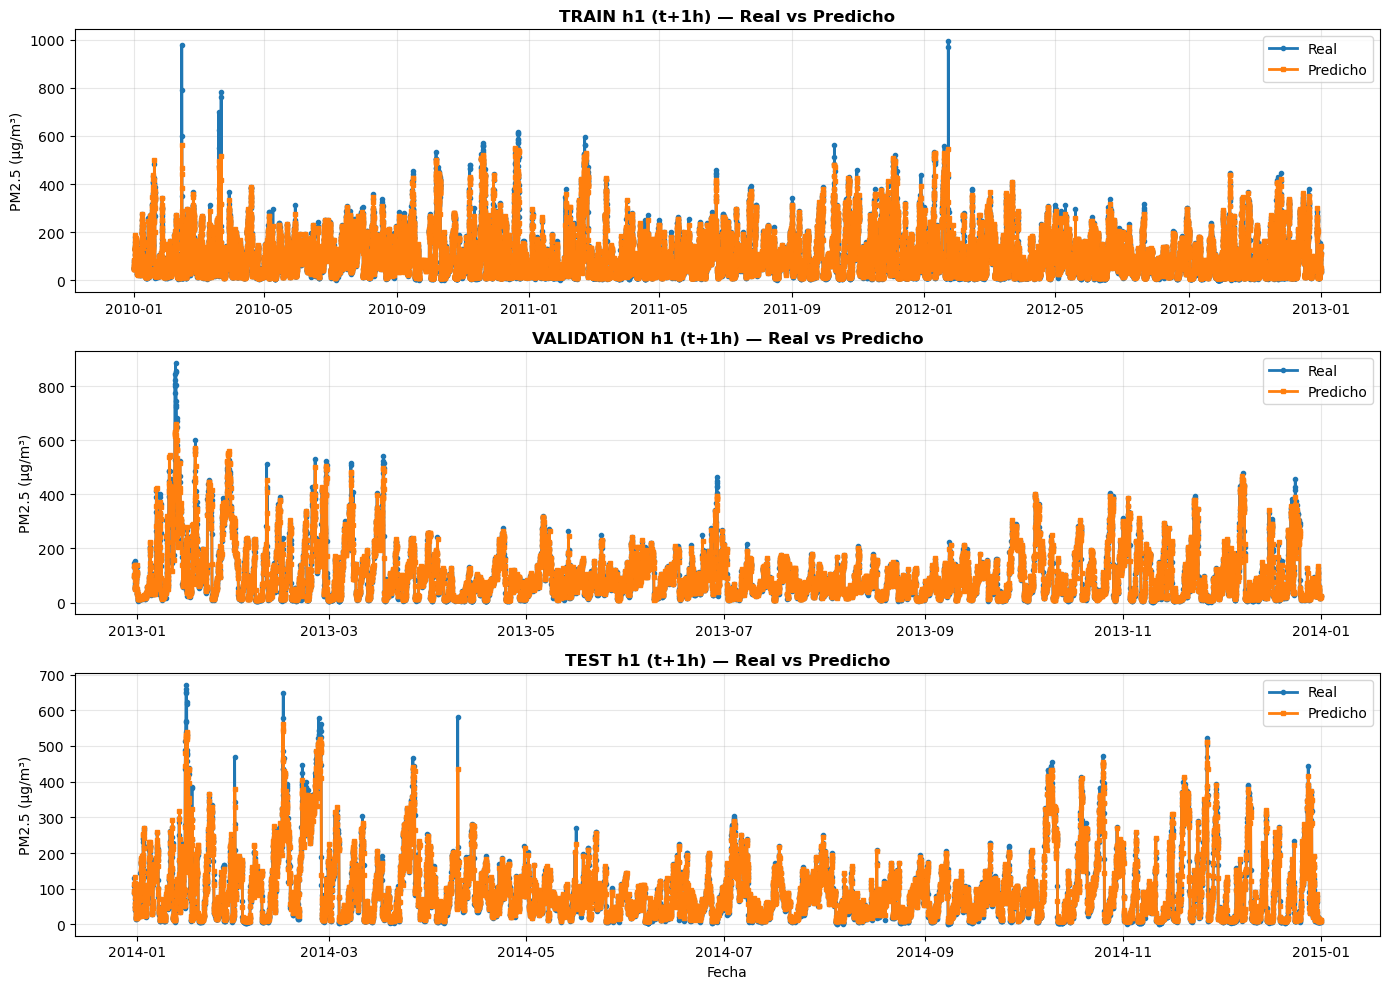

  ✓ Predicciones guardadas: predicciones_xgb_h1.csv

  ENTRENANDO HORIZONTE h2  (target: pm2.5_(t+2))

[1/4] Split:  train=26,304  val=8,784  test=8,782

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 1.415054e-03
      best_iteration del mejor trial: 376
      Hiperparámetros:
        learning_rate: 0.0875
        max_depth: 4
        min_child_weight: 10
        subsample: 0.7287
        colsample_bytree: 0.855
        gamma: 0.002
        reg_alpha: 1.1462
        reg_lambda: 1.4265

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 195 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h2      Train  942.322 30.697 17.869 0.876 0.317
       h2 Validation 1079.323 32.853 19.158 0.887 0.330
       h2       Te

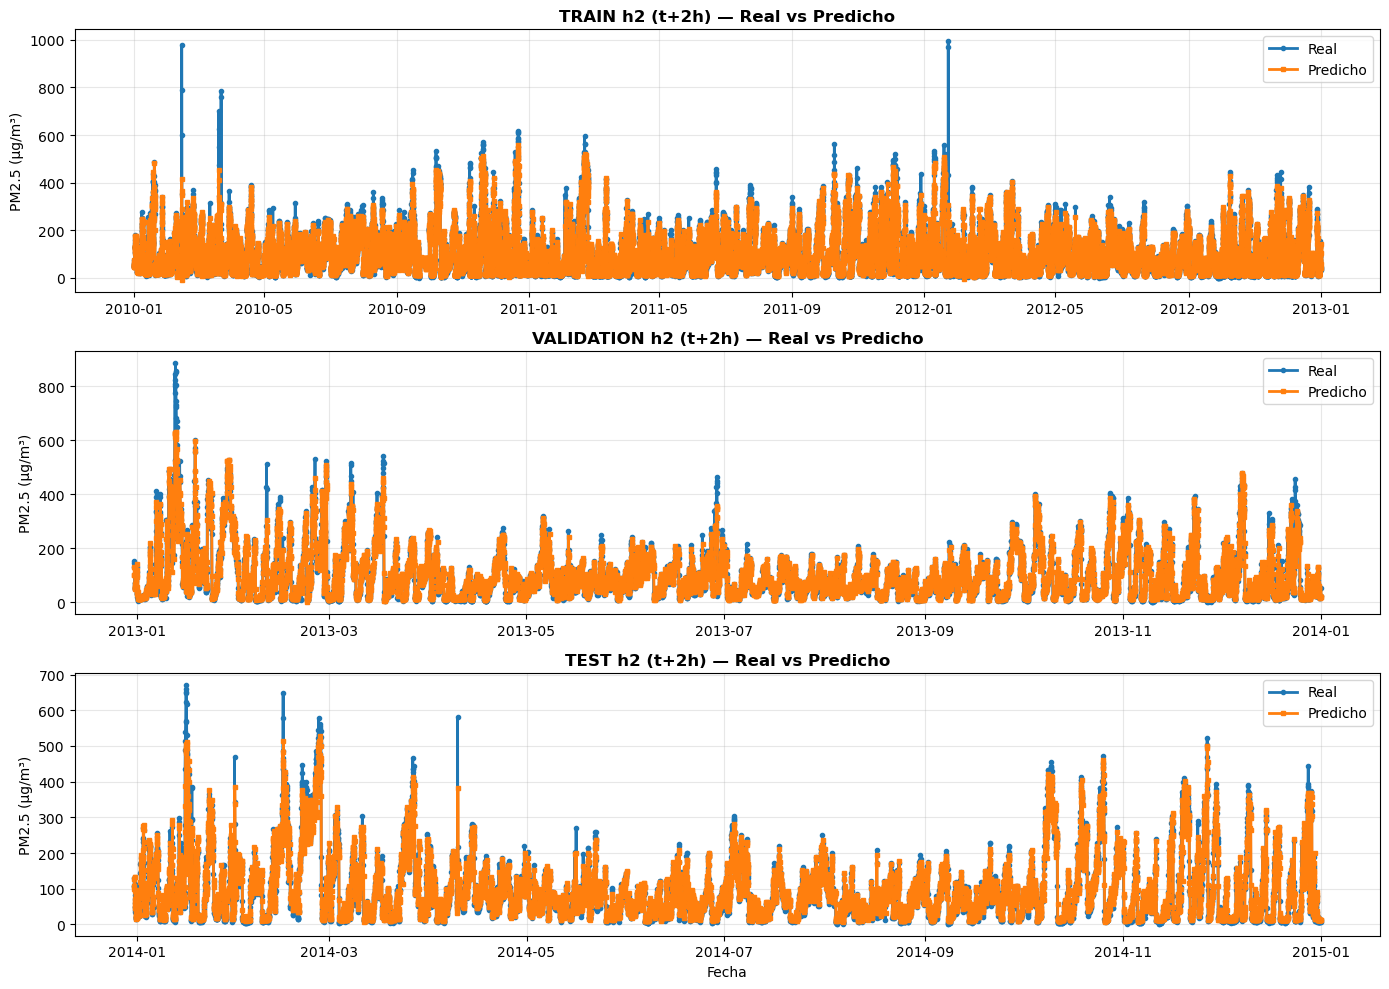

  ✓ Predicciones guardadas: predicciones_xgb_h2.csv

  ENTRENANDO HORIZONTE h3  (target: pm2.5_(t+3))

[1/4] Split:  train=26,304  val=8,784  test=8,781

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 2.082271e-03
      best_iteration del mejor trial: 701
      Hiperparámetros:
        learning_rate: 0.0526
        max_depth: 4
        min_child_weight: 5
        subsample: 0.8949
        colsample_bytree: 0.8282
        gamma: 0.0012
        reg_alpha: 2.0176
        reg_lambda: 0.1097

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 302 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h3      Train 1425.249 37.752 22.702 0.812 0.421
       h3 Validation 1664.248 40.795 24.764 0.826 0.457
       h3       T

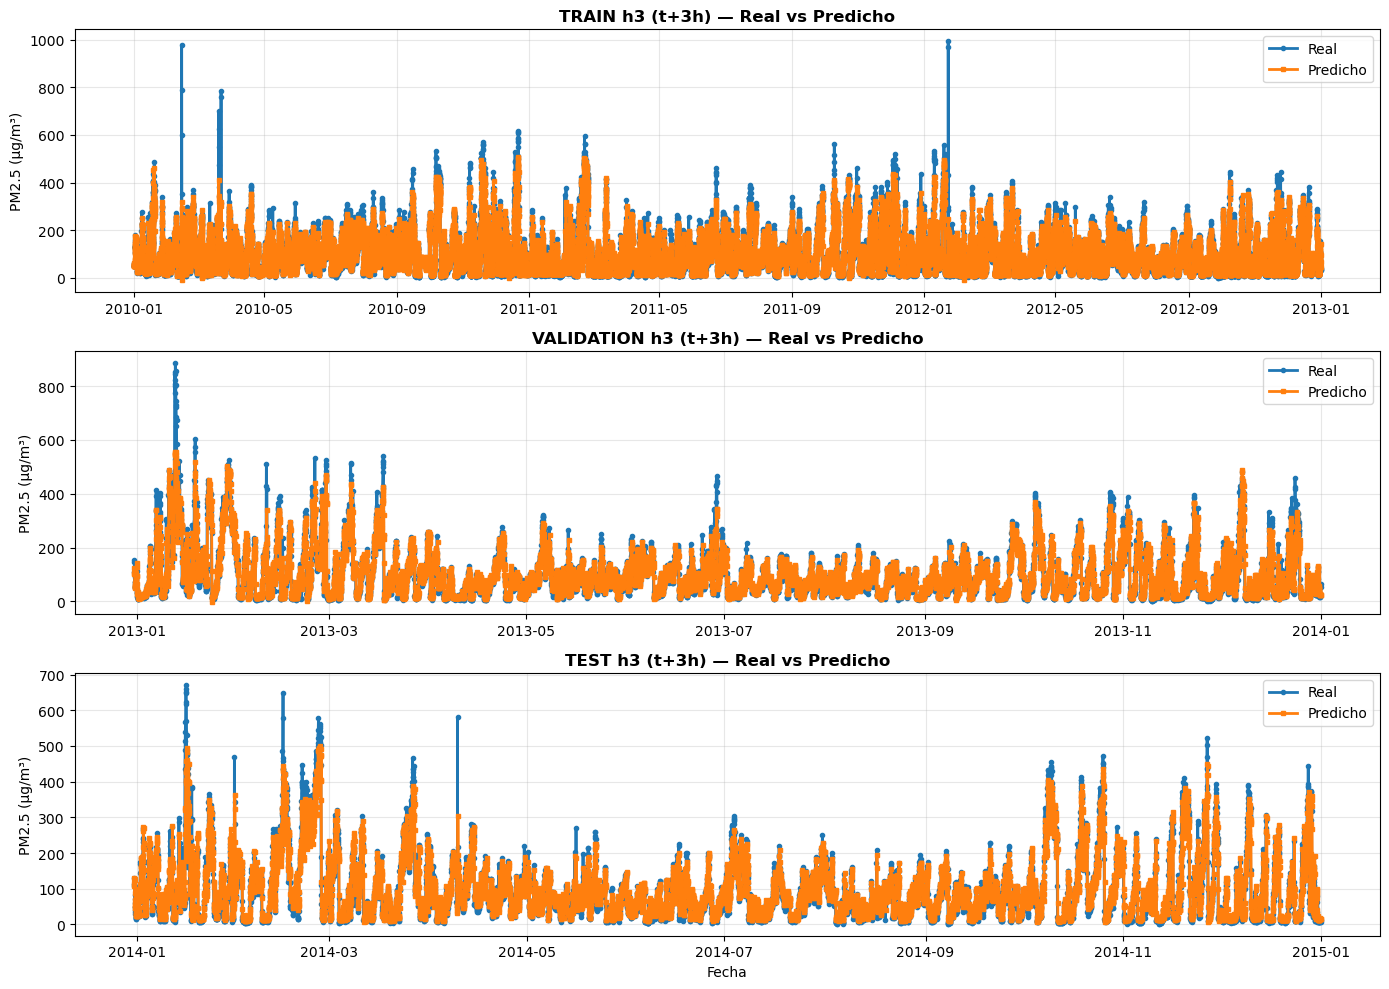

  ✓ Predicciones guardadas: predicciones_xgb_h3.csv

  ENTRENANDO HORIZONTE h4  (target: pm2.5_(t+4))

[1/4] Split:  train=26,304  val=8,784  test=8,780

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 2.665231e-03
      best_iteration del mejor trial: 1704
      Hiperparámetros:
        learning_rate: 0.0252
        max_depth: 4
        min_child_weight: 2
        subsample: 0.8441
        colsample_bytree: 0.859
        gamma: 0.0015
        reg_alpha: 2.3483
        reg_lambda: 0.6769

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 968 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h4      Train 1704.897 41.290 25.800 0.775 0.507
       h4 Validation 2006.127 44.790 28.245 0.790 0.553
       h4       T

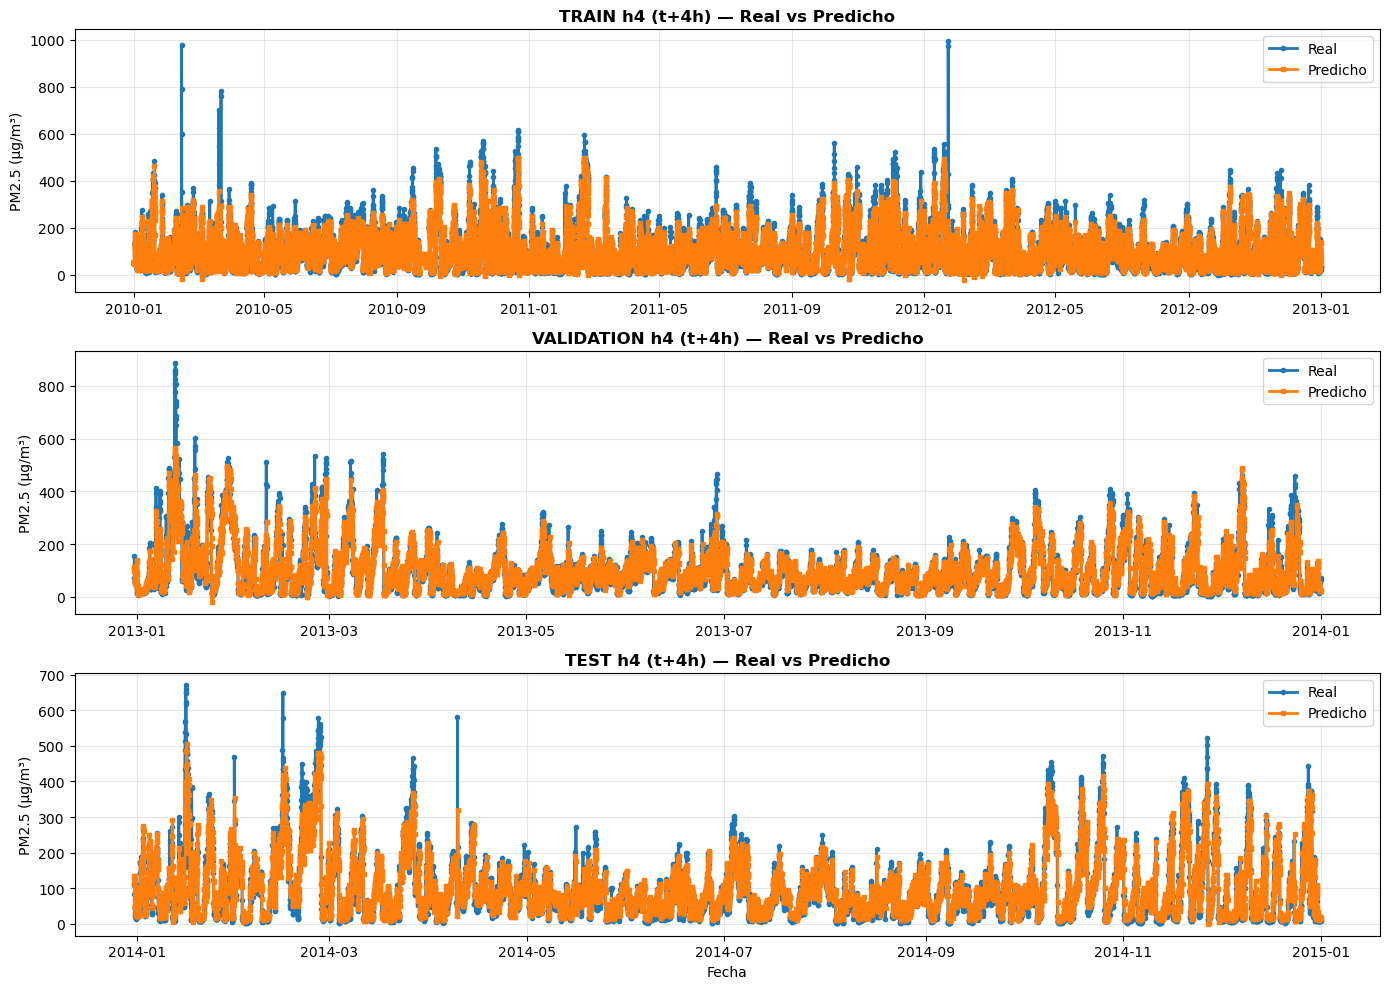

  ✓ Predicciones guardadas: predicciones_xgb_h4.csv

  ENTRENANDO HORIZONTE h5  (target: pm2.5_(t+5))

[1/4] Split:  train=26,304  val=8,784  test=8,779

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 3.187987e-03
      best_iteration del mejor trial: 245
      Hiperparámetros:
        learning_rate: 0.2106
        max_depth: 3
        min_child_weight: 6
        subsample: 0.6288
        colsample_bytree: 0.8906
        gamma: 0.0024
        reg_alpha: 1.7636
        reg_lambda: 0.0544

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 106 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h5      Train 2220.237 47.119 30.230 0.707 0.623
       h5 Validation 2612.126 51.109 32.991 0.727 0.678
       h5       T

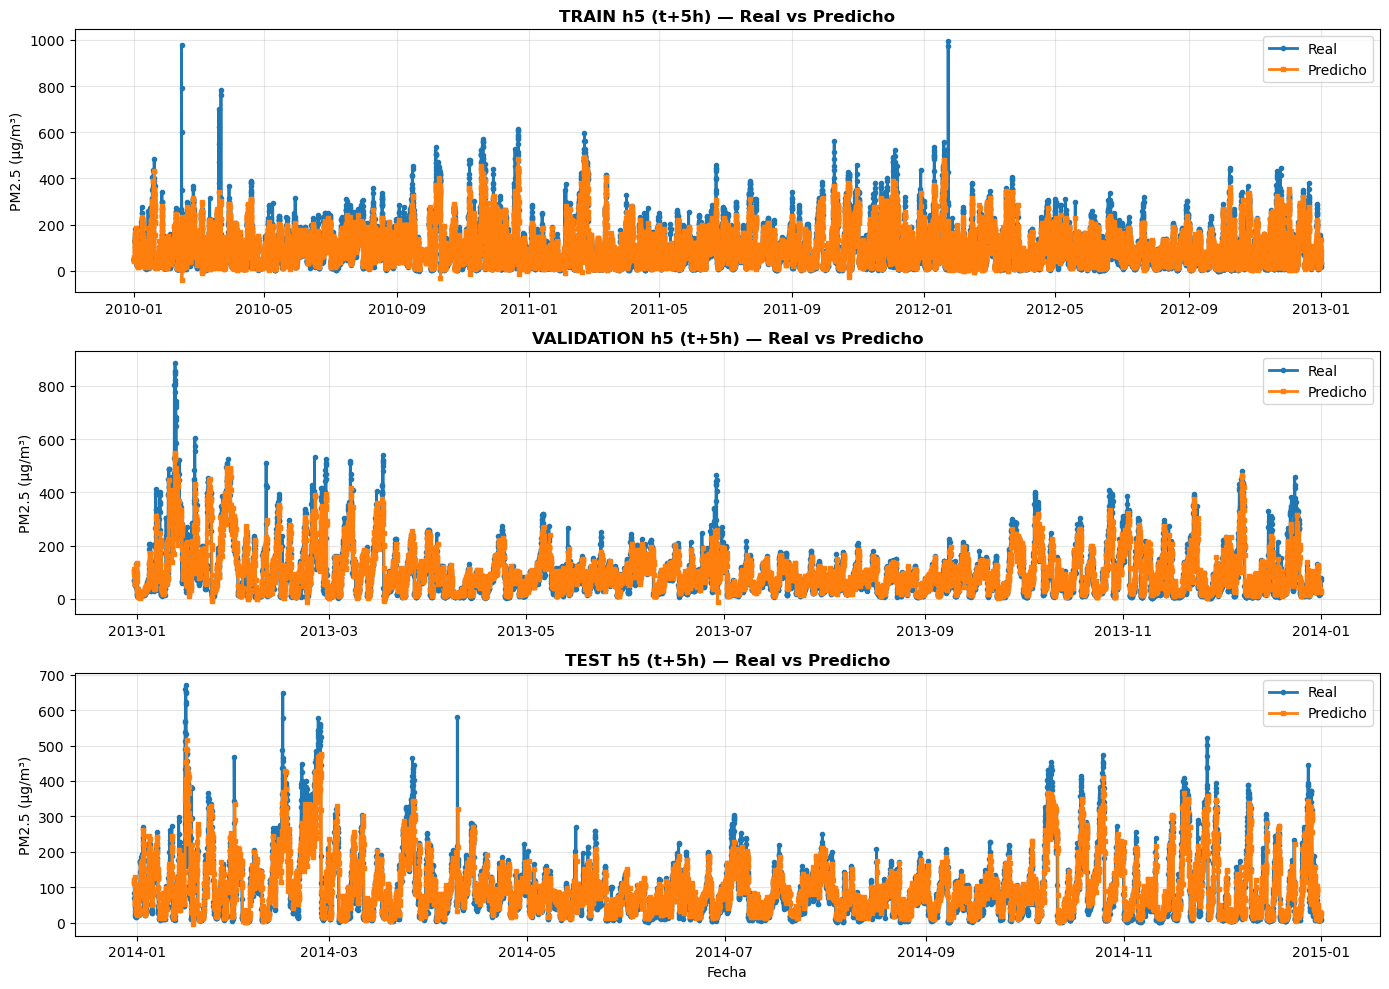

  ✓ Predicciones guardadas: predicciones_xgb_h5.csv

  ENTRENANDO HORIZONTE h6  (target: pm2.5_(t+6))

[1/4] Split:  train=26,304  val=8,784  test=8,778

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 3.664671e-03
      best_iteration del mejor trial: 1069
      Hiperparámetros:
        learning_rate: 0.0144
        max_depth: 5
        min_child_weight: 6
        subsample: 0.6318
        colsample_bytree: 0.7007
        gamma: 0.0018
        reg_alpha: 1.2587
        reg_lambda: 0.8253

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 741 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h6      Train 2250.795 47.443 31.127 0.703 0.671
       h6 Validation 2563.447 50.630 33.776 0.732 0.725
       h6       

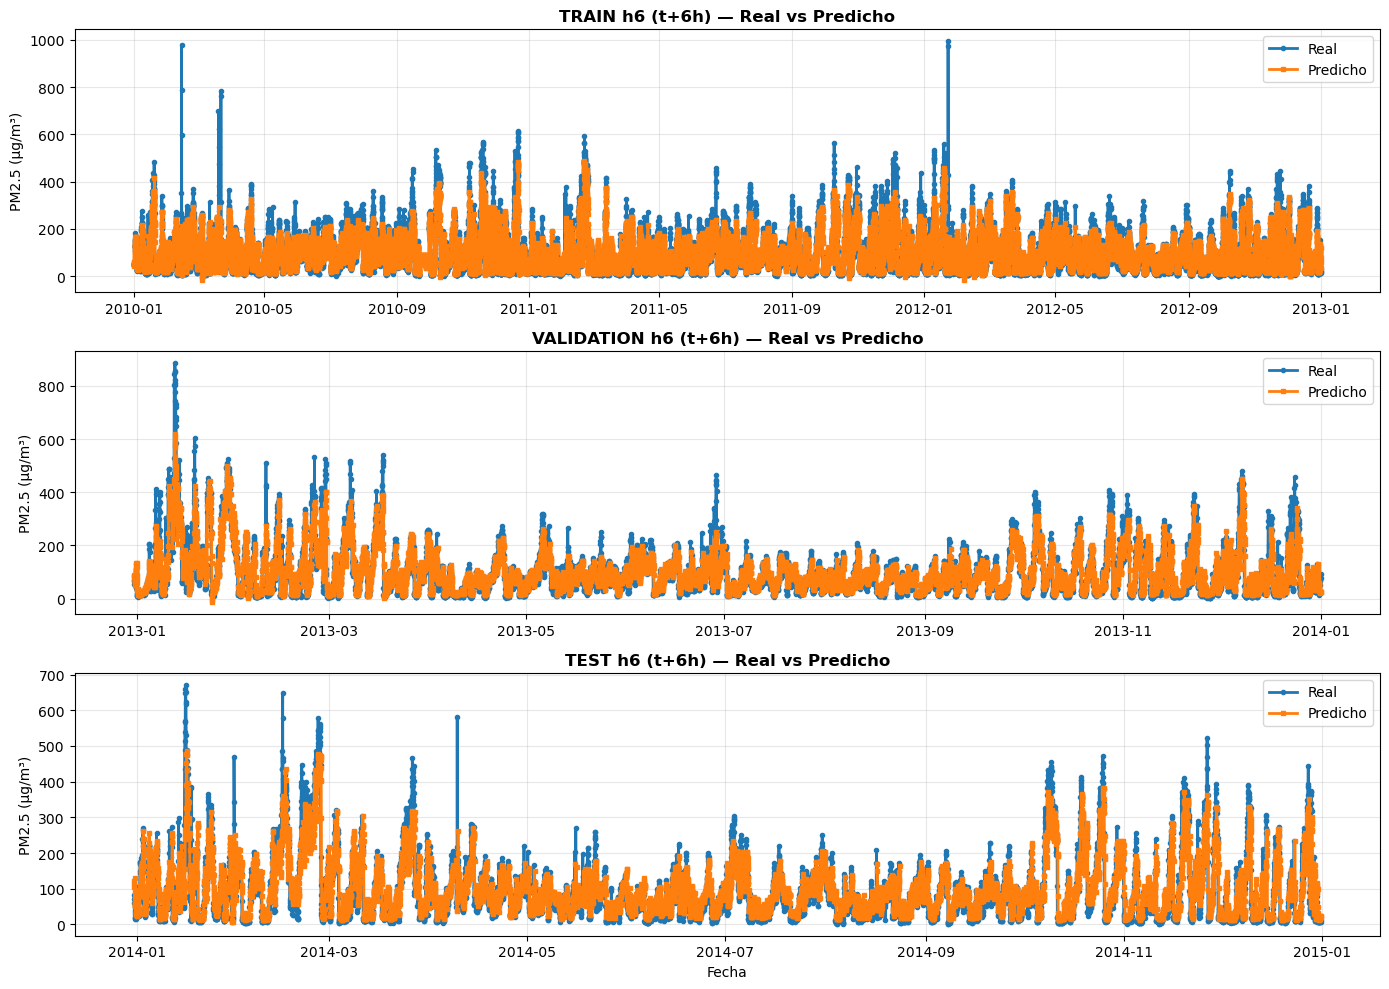

  ✓ Predicciones guardadas: predicciones_xgb_h6.csv

  ENTRENANDO HORIZONTE h7  (target: pm2.5_(t+7))

[1/4] Split:  train=26,304  val=8,784  test=8,777

[2/4] Optuna (100 trials) buscando hiperparámetros...
      MSE_val óptimo (escalado): 4.012316e-03
      best_iteration del mejor trial: 1071
      Hiperparámetros:
        learning_rate: 0.0184
        max_depth: 6
        min_child_weight: 7
        subsample: 0.7869
        colsample_bytree: 0.7507
        gamma: 0.0017
        reg_alpha: 0.8064
        reg_lambda: 0.0035

[3/4] Entrenando modelo final (Opción C):
      Entrenamiento final: 34,209 filas (train + 90% de val)
      Holdout early-stop:  879 filas (último 10% de val)
      best_iteration del modelo final: 520 árboles

[4/4] Predicciones y métricas...

  Métricas (escala original µg/m³):
horizonte        Set      MSE   RMSE    MAE    R2  MAPE
       h7      Train 2123.268 46.079 31.006 0.720 0.690
       h7 Validation 2423.216 49.226 33.767 0.747 0.755
       h7       

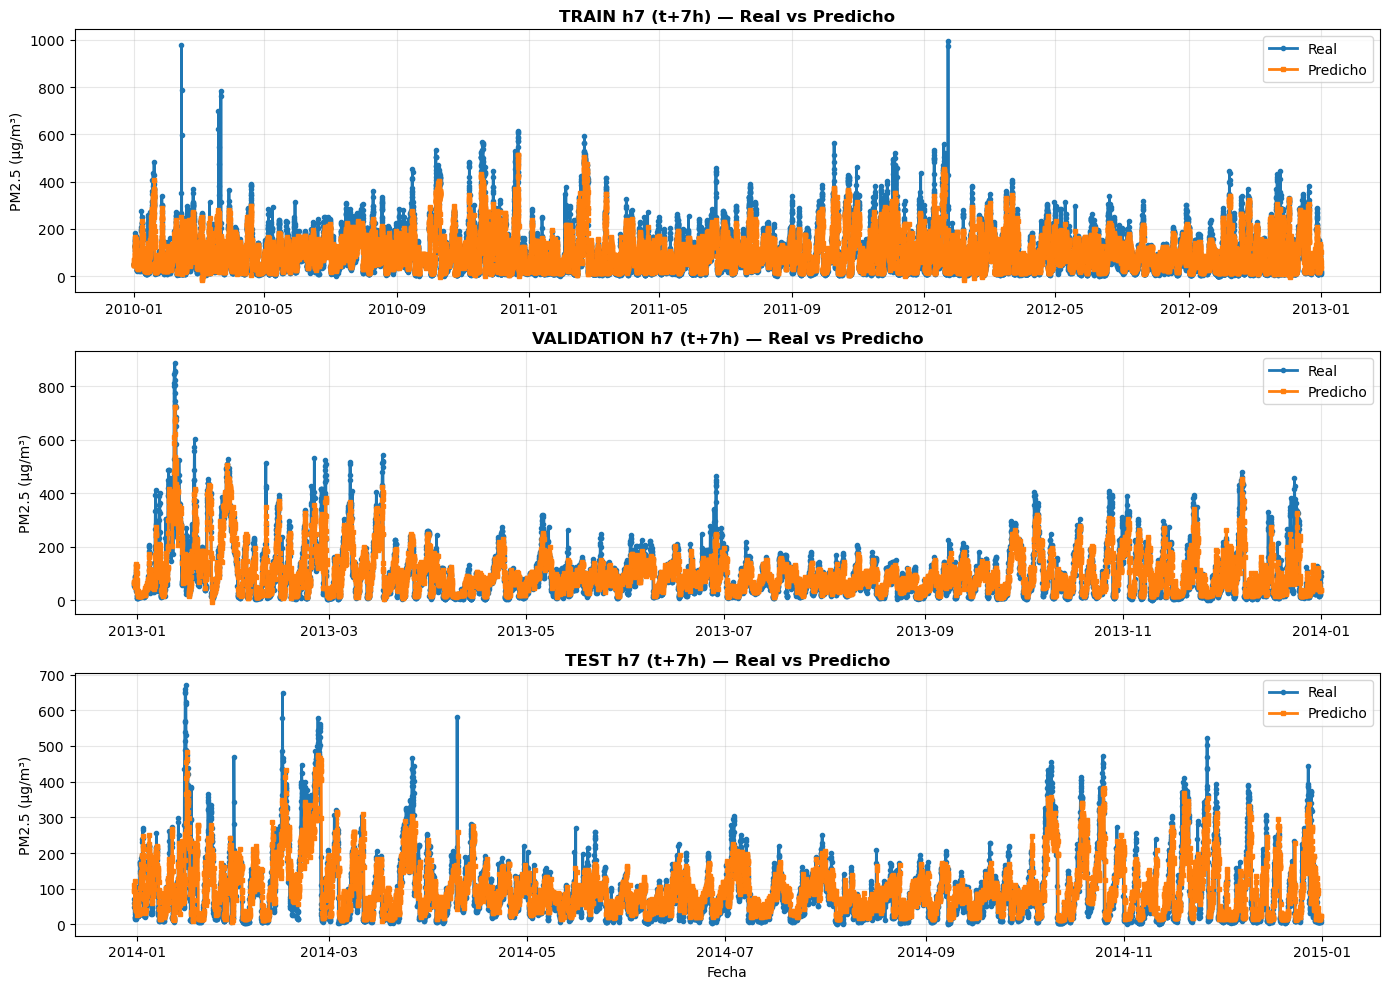

  ✓ Predicciones guardadas: predicciones_xgb_h7.csv

  ✓ Entrenamiento completado para los 7 horizontes


In [23]:
# Parámetros globales del entrenamiento
N_TRIALS = 100            # trials por horizonte (50 = búsqueda fina; baja a 20-30 para iterar rápido)
ES_ROUNDS = 50           # tolerancia de early stopping (50 iteraciones sin mejora → para)
N_EST_MAX = 2000         # techo alto de árboles; early stopping decide el real

resultados = {}
for h in range(1, MAX_HORIZON + 1):
    resultados[f"h{h}"] = entrenar_horizonte(h,
                                             n_trials=N_TRIALS,
                                             es_rounds=ES_ROUNDS,
                                             n_estimators_max=N_EST_MAX,
                                             verbose=True)

print("\n" + "=" * 80)
print(f"  ✓ Entrenamiento completado para los {MAX_HORIZON} horizontes")
print("=" * 80)

## Tabla resumen — degradación de métricas con el horizonte

El análisis más útil del enfoque por horizontes es ver **cómo se degrada cada métrica al pronosticar más lejos**. La expectativa teórica (sección 14 del EDA): el R² baja porque la autocorrelación cae, el MAE/RMSE suben.

In [24]:
# Concatenamos las métricas de los 7 horizontes
df_metricas = pd.concat([resultados[f"h{h}"]["metrics"] for h in range(1, MAX_HORIZON + 1)],
                        ignore_index=True)

# Vista pivotada por set para leer cómo se degrada cada métrica con el horizonte
print("\n=== MÉTRICAS POR HORIZONTE Y SET (escala original, µg/m³) ===\n")
for set_name in ["Train", "Validation", "Test"]:
    print(f"\n--- {set_name} ---")
    print(df_metricas[df_metricas["Set"] == set_name]
          .set_index("horizonte")[["MSE", "RMSE", "MAE", "R2", "MAPE"]]
          .round(3))


=== MÉTRICAS POR HORIZONTE Y SET (escala original, µg/m³) ===


--- Train ---
                MSE    RMSE     MAE     R2   MAPE
horizonte                                        
h1          466.543  21.600  11.889  0.938  0.205
h2          942.322  30.697  17.869  0.876  0.317
h3         1425.249  37.752  22.702  0.812  0.421
h4         1704.897  41.290  25.800  0.775  0.507
h5         2220.237  47.119  30.230  0.707  0.623
h6         2250.795  47.443  31.127  0.703  0.671
h7         2123.268  46.079  31.006  0.720  0.690

--- Validation ---
                MSE    RMSE     MAE     R2   MAPE
horizonte                                        
h1          534.135  23.111  12.558  0.944  0.206
h2         1079.323  32.853  19.158  0.887  0.330
h3         1664.248  40.795  24.764  0.826  0.457
h4         2006.127  44.790  28.245  0.790  0.553
h5         2612.126  51.109  32.991  0.727  0.678
h6         2563.447  50.630  33.776  0.732  0.725
h7         2423.216  49.226  33.767  0.747  0.755



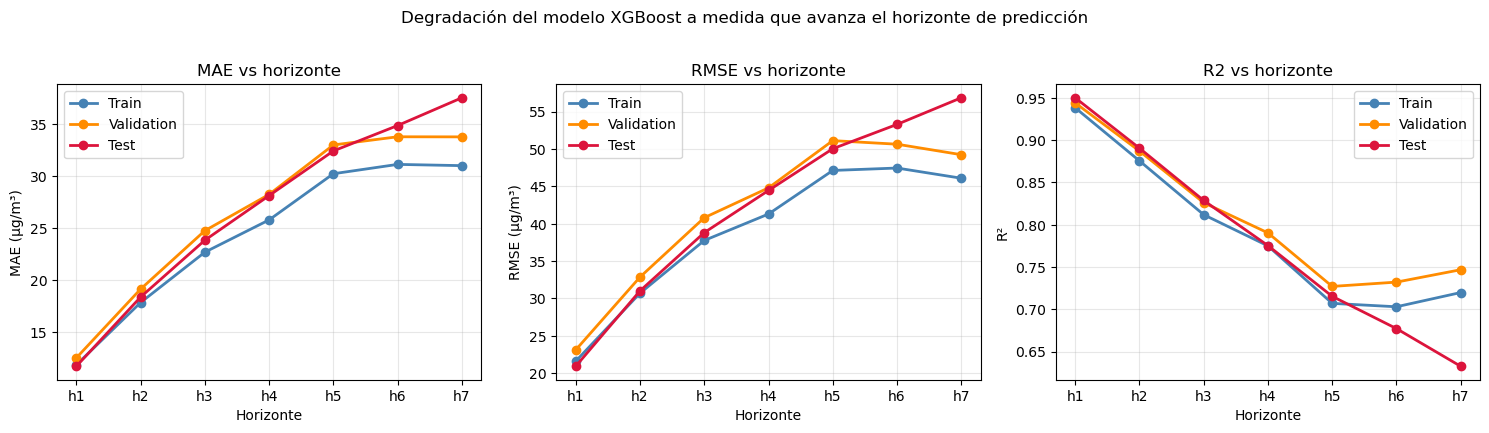

In [25]:
# Gráficos: degradación de MAE, RMSE y R² vs horizonte, por set
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

for ax, metric, ylabel in zip(axes, ["MAE", "RMSE", "R2"],
                              ["MAE (µg/m³)", "RMSE (µg/m³)", "R²"]):
    for set_name, color in zip(["Train", "Validation", "Test"],
                                ["steelblue", "darkorange", "crimson"]):
        sub = df_metricas[df_metricas["Set"] == set_name]
        ax.plot(sub["horizonte"], sub[metric], marker="o", lw=2, label=set_name, color=color)
    ax.set_xlabel("Horizonte")
    ax.set_ylabel(ylabel)
    ax.set_title(f"{metric} vs horizonte")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Degradación del modelo XGBoost a medida que avanza el horizonte de predicción",
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

In [26]:
# Tabla de best_iteration y best_params por horizonte (útil para reporte)
filas_resumen = []
for h in range(1, MAX_HORIZON + 1):
    r = resultados[f"h{h}"]
    fila = {"horizonte": f"h{h}", "best_iteration": r["best_iteration"]}
    fila.update({k: round(v, 4) if isinstance(v, float) else v
                 for k, v in r["best_params"].items()})
    filas_resumen.append(fila)

resumen_hiperparams = pd.DataFrame(filas_resumen).set_index("horizonte")
print("\n=== HIPERPARÁMETROS ÓPTIMOS Y NÚMERO DE ÁRBOLES POR HORIZONTE ===\n")
print(resumen_hiperparams)


=== HIPERPARÁMETROS ÓPTIMOS Y NÚMERO DE ÁRBOLES POR HORIZONTE ===

           best_iteration  learning_rate  max_depth  min_child_weight  \
horizonte                                                               
h1                    372         0.0452          4                 7   
h2                    195         0.0875          4                10   
h3                    302         0.0526          4                 5   
h4                    968         0.0252          4                 2   
h5                    106         0.2106          3                 6   
h6                    741         0.0144          5                 6   
h7                    520         0.0184          6                 7   

           subsample  colsample_bytree   gamma  reg_alpha  reg_lambda  
horizonte                                                              
h1            0.7732            0.6564  0.0014     1.2409      0.0112  
h2            0.7287            0.8550  0.0020     1.1462 

## Visualización: predicciones vs real por horizonte (test set)

Para cada horizonte mostramos una ventana del test set (las primeras 14 días de 2014) — eso permite ver visualmente si el modelo captura los picos.

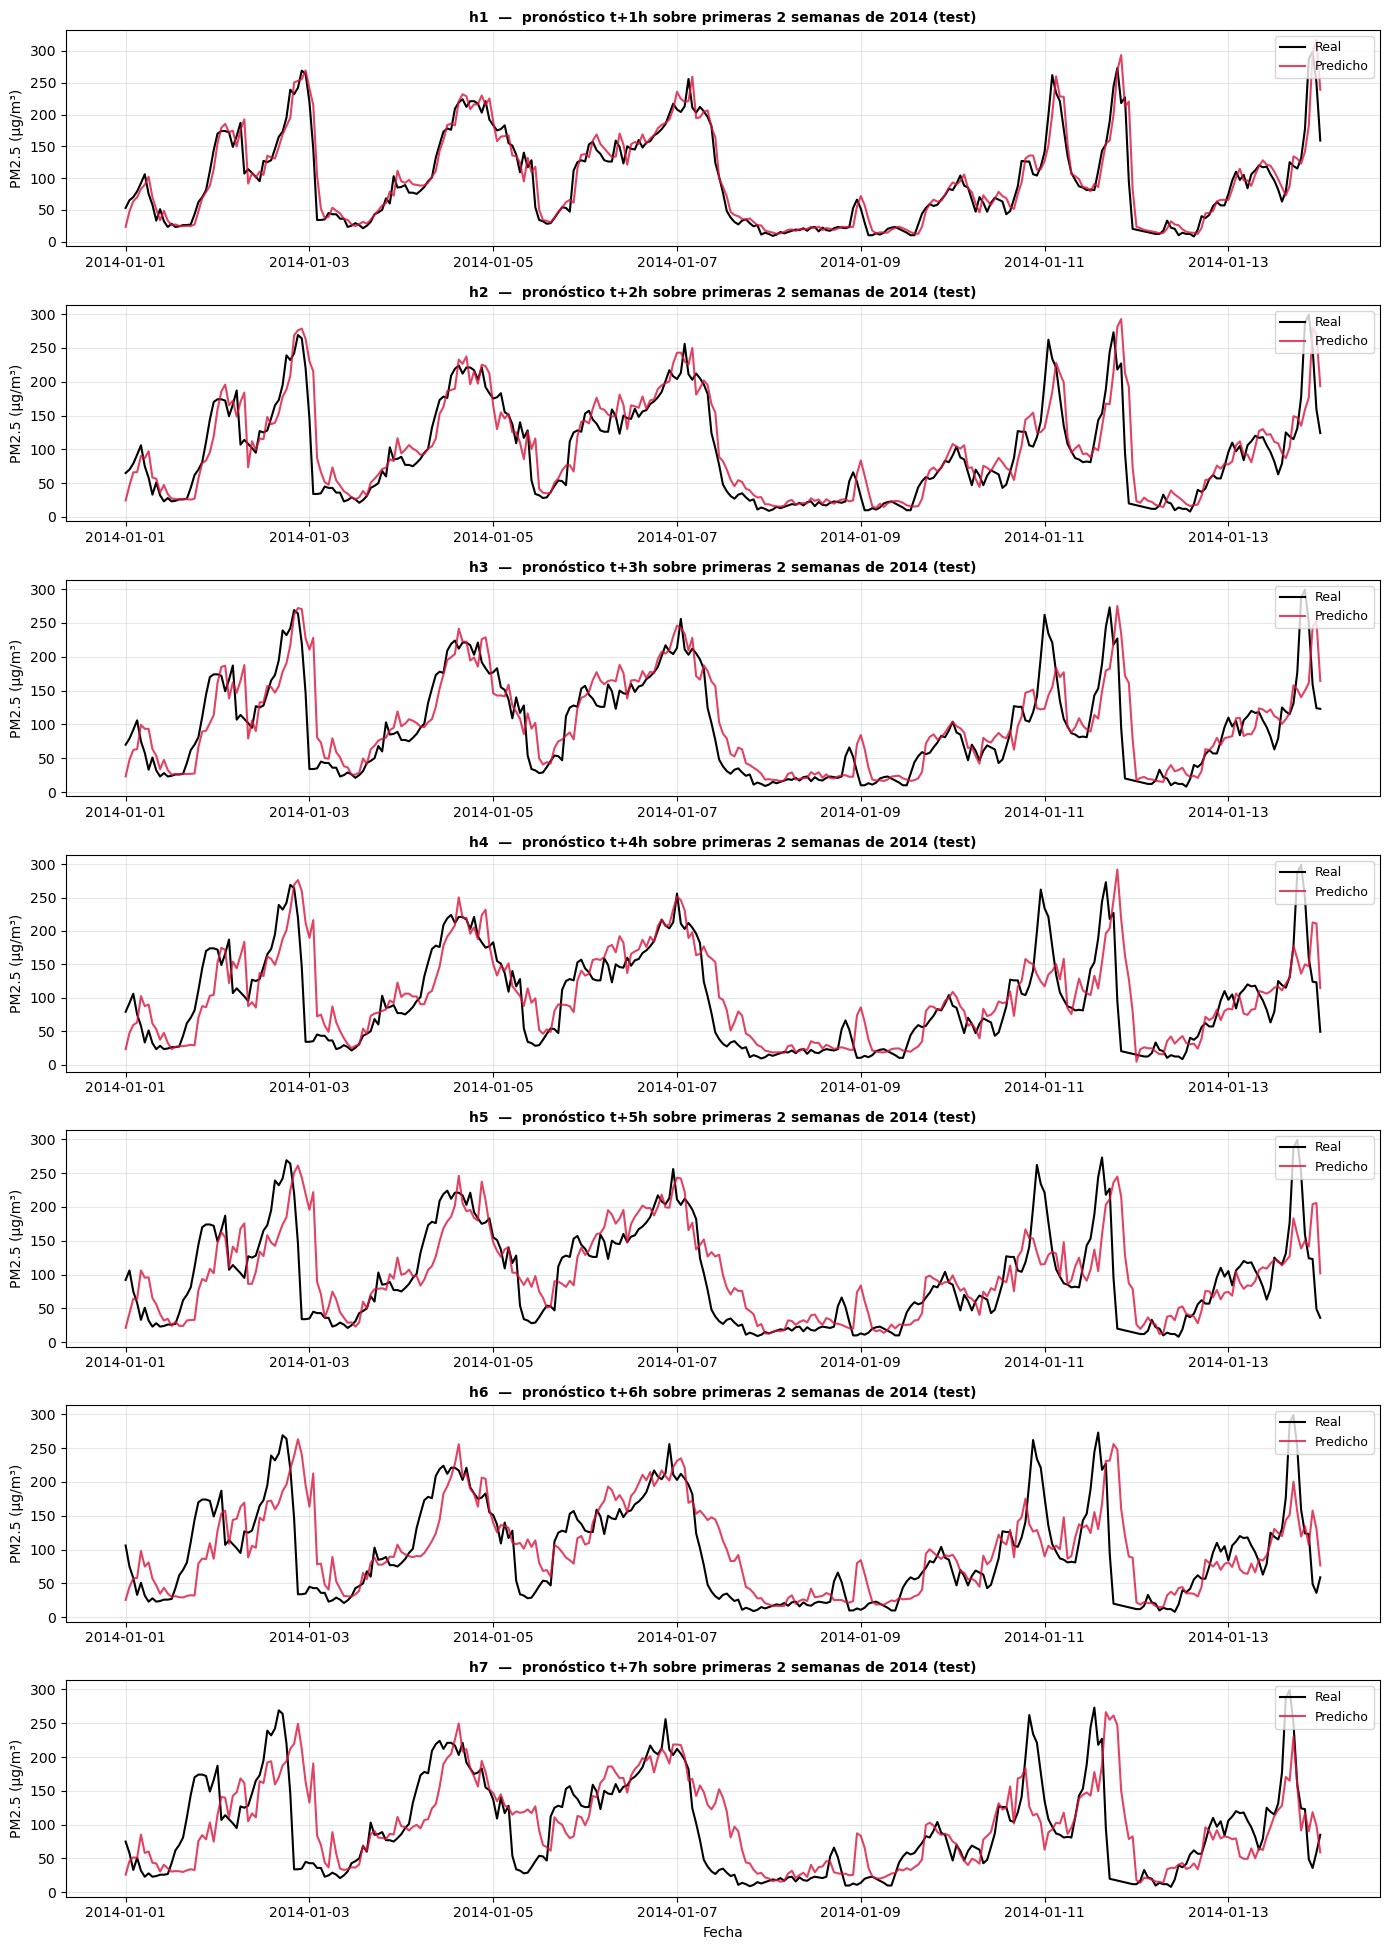

In [27]:
fig, axes = plt.subplots(MAX_HORIZON, 1, figsize=(14, 2.8 * MAX_HORIZON))

# Ventana de visualización (primeras 2 semanas de test)
v_ini = pd.Timestamp("2014-01-01")
v_fin = pd.Timestamp("2014-01-14")

for i, h in enumerate(range(1, MAX_HORIZON + 1)):
    ax = axes[i]
    res = resultados[f"h{h}"]["results"]
    test_data = res[res["set"] == "test"].loc[v_ini:v_fin]

    ax.plot(test_data.index, test_data["real"],
            label="Real", color="black", lw=1.5)
    ax.plot(test_data.index, test_data["predicho"],
            label="Predicho", color="crimson", lw=1.5, alpha=0.8)
    ax.set_title(f"h{h}  —  pronóstico t+{h}h sobre primeras 2 semanas de 2014 (test)",
                 fontsize=10, fontweight="bold")
    ax.set_ylabel("PM2.5 (µg/m³)")
    ax.legend(loc="upper right", fontsize=9)
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Fecha")
plt.tight_layout()
plt.show()

## Importancia de features

XGBoost expone tres tipos de importancia:
- **gain**: ganancia promedio aportada por la feature en los splits donde aparece (el más informativo).
- **weight**: número de veces que la feature se usa para splittear.
- **cover**: cobertura promedio (número de muestras afectadas por los splits con esa feature).

Mostramos `gain` para h1 (horizonte corto) y h6 (objetivo del proyecto).


=== IMPORTANCIA — h1 ===


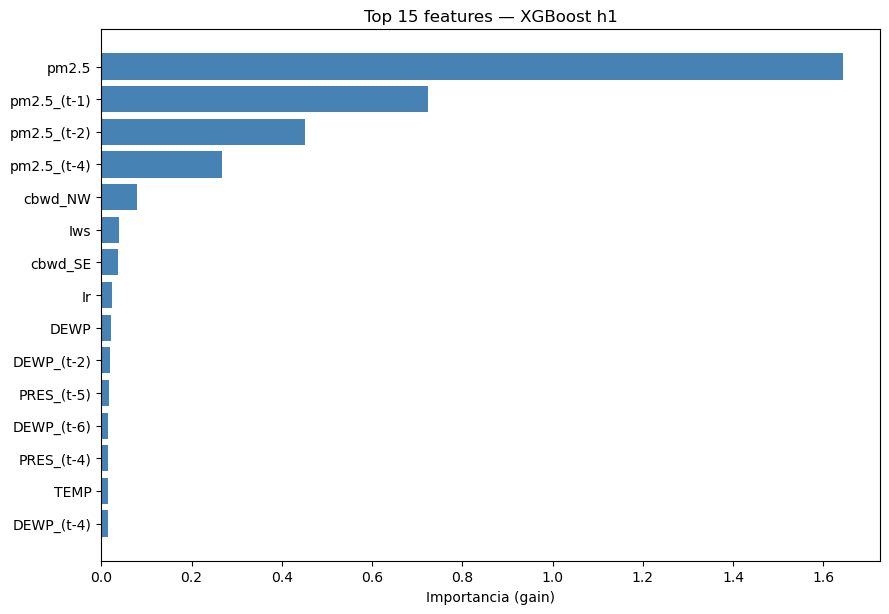

    feature     gain
      pm2.5 1.643136
pm2.5_(t-1) 0.723168
pm2.5_(t-2) 0.452014
pm2.5_(t-4) 0.267118
    cbwd_NW 0.078235
        Iws 0.038559
    cbwd_SE 0.036307
         Ir 0.023574
       DEWP 0.020879
 DEWP_(t-2) 0.019226
 PRES_(t-5) 0.016888
 DEWP_(t-6) 0.014937
 PRES_(t-4) 0.014839
       TEMP 0.014091
 DEWP_(t-4) 0.014015


In [28]:
def plot_importance(h, top_n=15):
    model = resultados[f"h{h}"]["model"]
    booster = model.get_booster()

    # Obtenemos importancia tipo "gain"
    importance = booster.get_score(importance_type="gain")
    # XGBoost devuelve features con nombres f0, f1, ... si no se pasó feature_names.
    # Pero como usamos pandas DataFrame, los nombres reales se conservan.
    df_imp = pd.DataFrame(importance.items(), columns=["feature", "gain"])
    df_imp = df_imp.sort_values("gain", ascending=False).head(top_n)

    fig, ax = plt.subplots(figsize=(9, 0.35 * top_n + 1))
    ax.barh(df_imp["feature"][::-1], df_imp["gain"][::-1], color="steelblue")
    ax.set_xlabel("Importancia (gain)")
    ax.set_title(f"Top {top_n} features — XGBoost h{h}")
    plt.tight_layout()
    plt.show()
    return df_imp

print("\n=== IMPORTANCIA — h1 ===")
imp_h1 = plot_importance(1, top_n=15)
print(imp_h1.to_string(index=False))


=== IMPORTANCIA — h6 ===


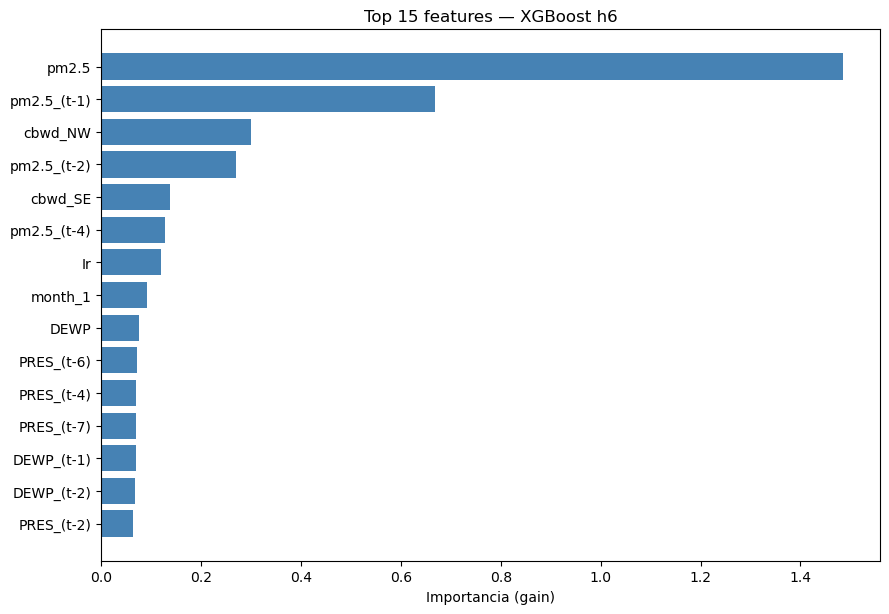

    feature     gain
      pm2.5 1.485059
pm2.5_(t-1) 0.668073
    cbwd_NW 0.299566
pm2.5_(t-2) 0.270446
    cbwd_SE 0.137365
pm2.5_(t-4) 0.127001
         Ir 0.119942
    month_1 0.091158
       DEWP 0.074764
 PRES_(t-6) 0.071746
 PRES_(t-4) 0.070251
 PRES_(t-7) 0.069273
 DEWP_(t-1) 0.069083
 DEWP_(t-2) 0.067329
 PRES_(t-2) 0.064353


In [29]:
print("\n=== IMPORTANCIA — h6 ===")
imp_h6 = plot_importance(6, top_n=15)
print(imp_h6.to_string(index=False))